In [1]:
import os
import glob
os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/"

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4 as nc

from xarray.groupers import UniqueGrouper
from xarray.groupers import SeasonGrouper

from matplotlib.ticker import MaxNLocator

import datetime
import cftime
import time

import gsw

mask_file = xr.open_dataset('/mnt/storage4/grace/data/model_masks/ANHA4_mesh_mask.nc')
bathy = xr.open_dataset('/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4_bathy_etopo1_gebco1.nc')

In [2]:
def time_bounds(startyear, startmonth, startday, endyear, endmonth, endday):
    return [startyear, startmonth, startday, endyear, endmonth, endday]

def get_times(dates):
    start_time = datetime.date(dates[0], dates[1], dates[2])
    end_time = datetime.date(dates[3], dates[4], dates[5])

    #figure out all the dates we have model files
    delta = end_time - start_time
    times = []

    i = 0
    while i < delta.days+1:
        t = start_time + datetime.timedelta(days=i)
        if t.month == 2 and t.day == 29:
            t = datetime.date(t.year, 3, 1)
            i = i+6
        else:
            i = i+5
        times.append(t)

    return times

def preprocess_t(ds):

    ds = ds[['sossheig', 'somxlts','e3t']]
    ds = ds.sel(y_grid_T = slice(250,450))
    ds = ds.sel(x_grid_T = slice(150,375))

    return ds

In [3]:
def get_files(path, runid, times):
    #need both the u and v components of velocity

    mdl_files_t = []
    for t in times:
        mdl_files_t.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridT.nc")
    dt = xr.open_mfdataset(mdl_files_t, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_t)
    t = dt.resample(time_counter='ME').mean()
    return dt, t

GET TEOS DATA

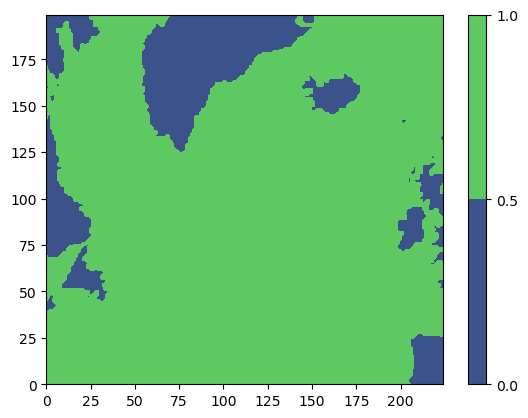

In [4]:
land_mask = np.ma.make_mask(mask_file['tmask'][0,0,250:450, 150:375])
plt.contourf(land_mask)
plt.colorbar()

In [5]:
file_pattern = '/mnt/storage4/grace/data/EGK503/*_gridT.nc'
filenames = glob.glob(file_pattern)
teos_5d = xr.open_mfdataset(filenames, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_t)
teos_monthly = teos_5d.resample(time_counter='ME').mean()

In [6]:
#teos_month = np.where(land_mask, teos_monthly['somxlts'], np.nan)

In [7]:
#teos_monthly.to_netcdf('/mnt/storage4/grace/data/EGK503_monthly.nc')

GET EOS DATA

In [8]:
file_pattern = '/mnt/storage4/grace/data/EGK501t/*_gridT.nc'
filenames = glob.glob(file_pattern)
eos_5d = xr.open_mfdataset(filenames, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_t)
eos_monthly = eos_5d.resample(time_counter='ME').mean()

In [10]:
#eos5d = eos_5d['somxlts'].groupby(['time_counter.year'])
eosmy = eos_monthly['somxlts'].groupby('time_counter.year')


In [13]:
#teos5d = teos_5d['somxlts'].groupby(['time_counter.year']
teosmy = teos_monthly['somxlts'].groupby(['time_counter.year'])

this cell gets the monthly and 5-day maxes for MLD by year

In [15]:
years = np.arange(2002, 2022, 1)

teos5max = np.zeros(len(years))
teosmonthmax = np.zeros(len(years))

eos5max = np.zeros(len(years))
eosmonthmax = np.zeros(len(years))

counter = 0
for year in years:
    #teos5max[counter] = np.nanmax(teos5d[year])
    teosmonthmax[counter] = np.nanmax(teosmy[year])
    #eos5max[counter] = np.nanmax(eos5d[year])
    eosmonthmax[counter] = np.nanmax(eosmy[year])
    counter += 1

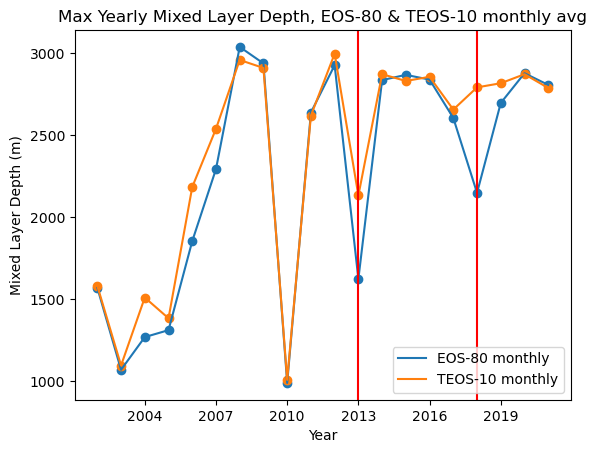

In [12]:
plt.scatter(years, eosmonthmax)
plt.plot(years, eosmonthmax, label = 'EOS-80 monthly')
plt.scatter(years, teosmonthmax)
plt.plot(years, teosmonthmax, label ='TEOS-10 monthly')
plt.axvline(2013, c = 'red')
plt.axvline(2018, c = 'red')
#plt.axvline(2004, c = 'red')
#plt.axvline(2005, c = 'red')
#plt.axvline(2006, c = 'red')
#plt.axvline(2007, c = 'red')

plt.xlabel('Year')
plt.ylabel('Mixed Layer Depth (m)')
plt.title('Max Yearly Mixed Layer Depth, EOS-80 & TEOS-10 monthly avg')
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=7))
plt.legend()

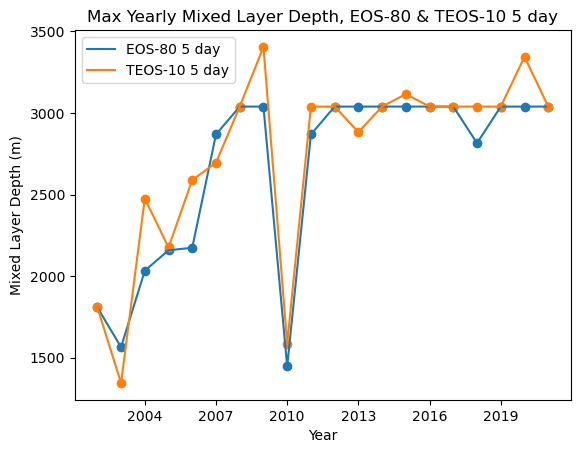

In [13]:
plt.scatter(years, eos5max)
plt.plot(years, eos5max, label = 'EOS-80 5 day')
plt.scatter(years, teos5max)
plt.plot(years, teos5max, label ='TEOS-10 5 day')
#plt.axvline(2013, c = 'red')
#plt.axvline(2018, c = 'red')
#plt.axvline(2004, c = 'red')
#plt.axvline(2005, c = 'red')
#plt.axvline(2006, c = 'red')
#plt.axvline(2007, c = 'red')

plt.xlabel('Year')
plt.ylabel('Mixed Layer Depth (m)')
plt.title('Max Yearly Mixed Layer Depth, EOS-80 & TEOS-10 5 day')
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=7))
plt.legend()

ok next do mean wintertime mld & map comparisons of 2005-2007, 2013, 2017, 2018, 2019
then send to paul
tell him you're working on arctic gateways

In [37]:
bath = bathy['Bathymetry'][250:450, 150:375]

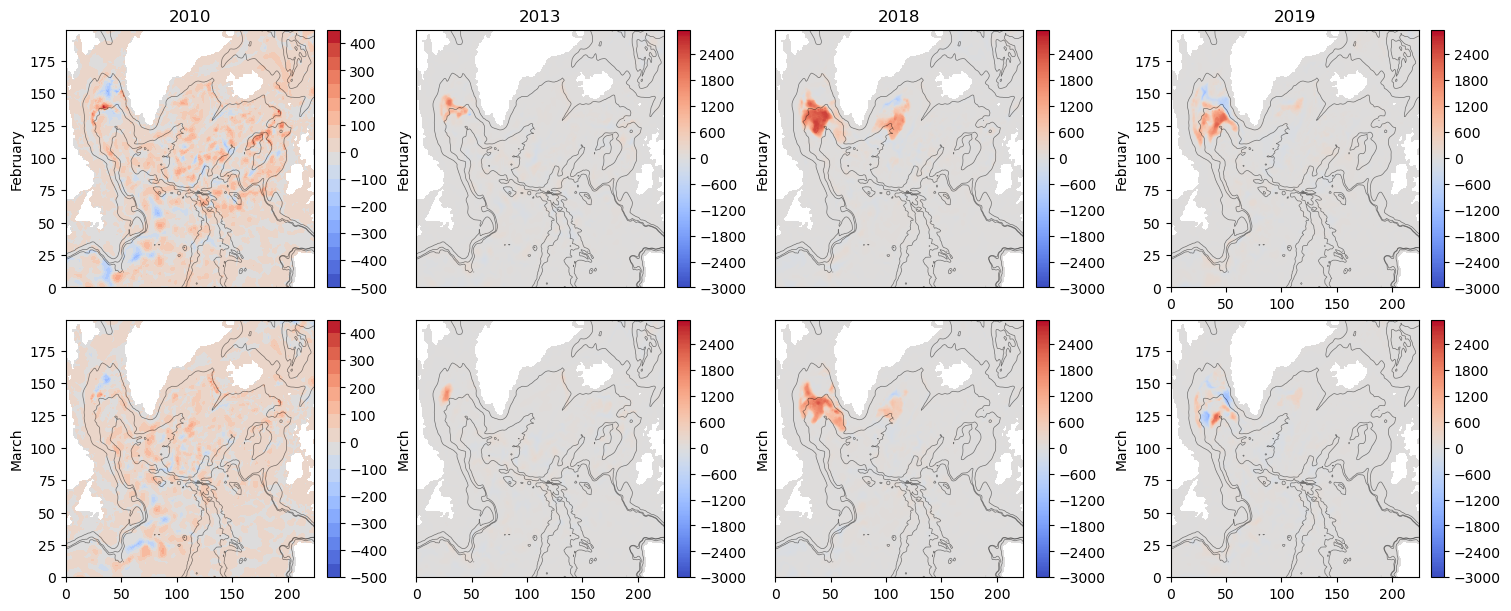

In [50]:
fig, axes = plt.subplots(2,4, layout='constrained', figsize = (15, 6))

bcmap = plt.colormaps['seismic'].with_extremes(bad='black')

axes[0,0].set_xticklabels([])
axes[0,0].set_xticks([])
axes[0,1].set_xticklabels([])
axes[0,1].set_xticks([])
axes[0,2].set_xticklabels([])
axes[0,2].set_xticks([])

axes[0,1].set_yticklabels([])
axes[0,1].set_yticks([])
axes[0,2].set_yticklabels([])
axes[0,2].set_yticks([])

axes[1,1].set_yticklabels([])
axes[1,1].set_yticks([])
axes[1,2].set_yticklabels([])
axes[1,2].set_yticks([])


axes[0,0].set_title('2010')
n = axes[0,0].contourf(np.where(land_mask, teosmy[2010][2,:,:] - eosmy[2010][2, :,:], np.nan), np.arange(-500, 500, 50), cmap='coolwarm')
axes[0,0].contour(bath, [1000, 3000, 3500], colors = 'black', alpha = .5, linewidths=.5)
axes[0,0].set_ylabel('February')
m = axes[1,0].contourf(np.where(land_mask, teosmy[2010][3,:,:] - eosmy[2010][3, :,:], np.nan), np.arange(-500, 500, 50), cmap='coolwarm')
axes[1,0].contour(bath, [1000, 3000, 3500], colors = 'black', alpha = .5, linewidths=.5)
axes[1,0].set_ylabel('March')
fig.colorbar(n, ax=axes[0,0])
fig.colorbar(m, ax=axes[1,0])

axes[0,1].set_title('2013')
o= axes[0,1].contourf(np.where(land_mask, teosmy[2013][2,:,:] - eosmy[2013][2, :,:], np.nan), np.arange(-3000, 3000, 30),cmap='coolwarm')
axes[0,1].contour(bath, [1000, 3000, 3500], colors = 'black', alpha = .5, linewidths=.5)
axes[0,1].set_ylabel('February')
p =axes[1,1].contourf(np.where(land_mask, teosmy[2013][3,:,:] - eosmy[2013][3, :,:], np.nan), np.arange(-3000, 3000, 30),cmap='coolwarm')
axes[1,1].contour(bath, [1000, 3000, 3500], colors = 'black', alpha = .5, linewidths=.5)
axes[1,1].set_ylabel('March')
fig.colorbar(o, ax=axes[0,1])
fig.colorbar(p, ax=axes[1,1])

axes[0,2].set_title('2018')
q=axes[0,2].contourf(np.where(land_mask, teosmy[2018][2,:,:] - eosmy[2018][2, :,:] , np.nan), np.arange(-3000, 3000, 30), cmap='coolwarm')
axes[0,2].contour(bath, [1000, 3000, 3500], colors = 'black', alpha = .5, linewidths=.5)
axes[0,2].set_ylabel('February')
r=axes[1,2].contourf(np.where(land_mask, teosmy[2018][3,:,:] - eosmy[2018][3, :,:] , np.nan), np.arange(-3000, 3000, 30), cmap='coolwarm')
axes[1,2].contour(bath, [1000, 3000, 3500], colors = 'black', alpha = .5, linewidths=.5)
axes[1,2].set_ylabel('March')
fig.colorbar(q, ax=axes[0,2])
fig.colorbar(r, ax=axes[1,2])

axes[0,3].set_title('2019')
s=axes[0,3].contourf(np.where(land_mask, teosmy[2019][2,:,:] - eosmy[2019][2, :,:] ,np.nan), np.arange(-3000, 3000, 30), cmap='coolwarm')
axes[0,3].contour(bath, [1000, 3000, 3500], colors = 'black', alpha = .5, linewidths=.5)
axes[0,3].set_ylabel('February')
t=axes[1,3].contourf(np.where(land_mask, teosmy[2019][3,:,:] - eosmy[2019][3, :,:] ,np.nan), np.arange(-3000, 3000, 30), cmap='coolwarm')
axes[1,3].contour(bath, [1000, 3000, 3500], colors = 'black', alpha = .5, linewidths=.5)
axes[1,3].set_ylabel('March')
fig.colorbar(s, ax=axes[0,3])
fig.colorbar(t, ax=axes[1,3])


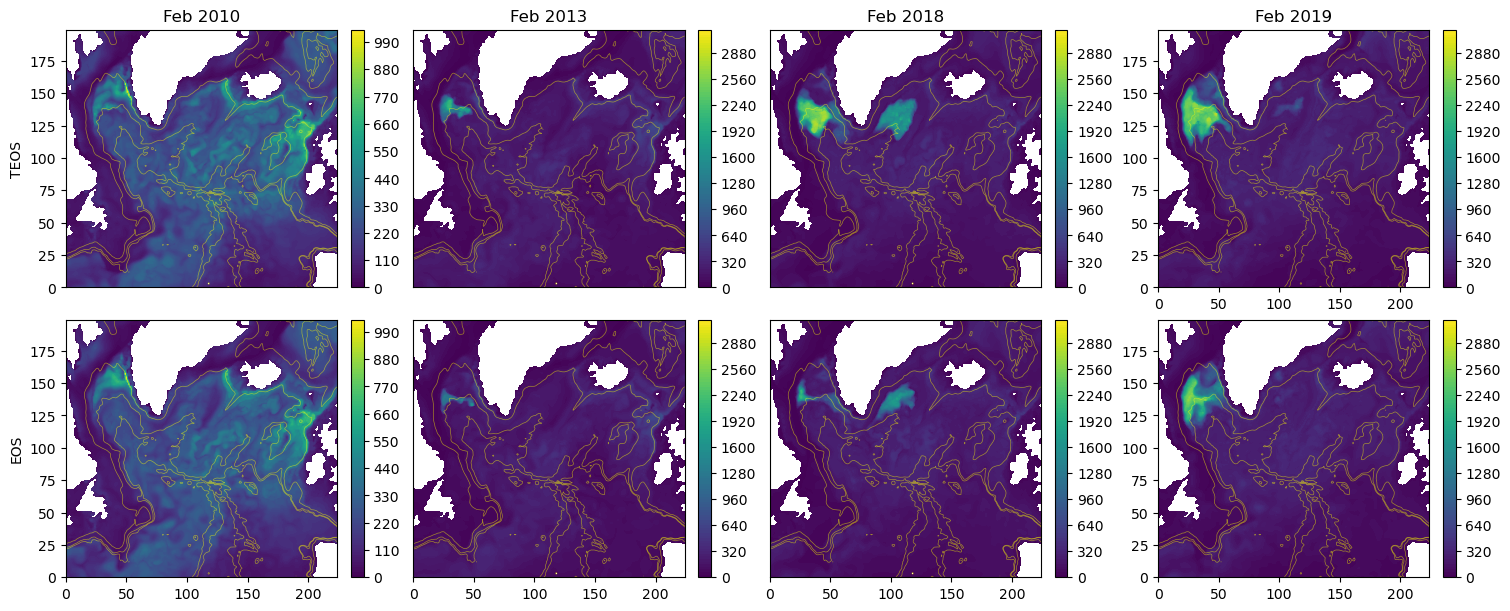

In [53]:
fig, axes = plt.subplots(2,4, layout='constrained', figsize = (15, 6))

axes[0,0].set_xticklabels([])
axes[0,0].set_xticks([])
axes[0,1].set_xticklabels([])
axes[0,1].set_xticks([])
axes[0,2].set_xticklabels([])
axes[0,2].set_xticks([])

axes[0,1].set_yticklabels([])
axes[0,1].set_yticks([])
axes[0,2].set_yticklabels([])
axes[0,2].set_yticks([])

axes[1,1].set_yticklabels([])
axes[1,1].set_yticks([])
axes[1,2].set_yticklabels([])
axes[1,2].set_yticks([])

axes[0,0].set_title('Feb 2010')
n = axes[0,0].contourf(np.where(land_mask, teosmy[2010][2,:,:], np.nan), np.arange(0, 1050, 10))
axes[0,0].contour(bath, [1000, 3000, 3500], colors = 'yellow', alpha = .5, linewidths=.5)
axes[0,0].set_ylabel('TEOS')
m = axes[1,0].contourf(np.where(land_mask, eosmy[2010][2, :,:], np.nan), np.arange(0, 1050, 10))
axes[1,0].contour(bath, [1000, 3000, 3500], colors = 'yellow', alpha = .5, linewidths=.5)
axes[1,0].set_ylabel('EOS')
fig.colorbar(n, ax=axes[0,0])
fig.colorbar(m, ax=axes[1,0])

axes[0,1].set_title('Feb 2013')
o= axes[0,1].contourf(np.where(land_mask, teosmy[2013][2,:,:], np.nan), np.arange(0, 3200, 32))
axes[0,1].contour(bath, [1000, 3000, 3500], colors = 'yellow', alpha = .5, linewidths=.5)
p =axes[1,1].contourf(np.where(land_mask, eosmy[2013][2, :,:], np.nan), np.arange(0, 3200, 32))
axes[1,1].contour(bath, [1000, 3000, 3500], colors = 'yellow', alpha = .5, linewidths=.5)
fig.colorbar(o, ax=axes[0,1])
fig.colorbar(p, ax=axes[1,1])

axes[0,2].set_title('Feb 2018')
q=axes[0,2].contourf(np.where(land_mask, teosmy[2018][2,:,:], np.nan), np.arange(0, 3200, 32))
axes[0,2].contour(bath, [1000, 3000, 3500], colors = 'yellow', alpha = .5, linewidths=.5)
r=axes[1,2].contourf(np.where(land_mask, eosmy[2018][2,:,:], np.nan), np.arange(0, 3200, 32) )
axes[1,2].contour(bath, [1000, 3000, 3500], colors = 'yellow', alpha = .5, linewidths=.5)
fig.colorbar(q, ax=axes[0,2])
fig.colorbar(r, ax=axes[1,2])

axes[0,3].set_title('Feb 2019')
s=axes[0,3].contourf(np.where(land_mask, teosmy[2019][2,:,:], np.nan), np.arange(0, 3200, 32))
axes[0,3].contour(bath, [1000, 3000, 3500], colors = 'yellow', alpha = .5, linewidths=.5)
t=axes[1,3].contourf(np.where(land_mask, eosmy[2019][2, :,:], np.nan), np.arange(0, 3200, 32))
axes[1,3].contour(bath, [1000, 3000, 3500], colors = 'yellow', alpha = .5, linewidths=.5)
fig.colorbar(s, ax=axes[0,3])
fig.colorbar(t, ax=axes[1,3])
